## Problem Statement

The dataset contains messy SMS text data including spam messages with noise such as special characters, URLs, phone numbers, and inconsistent casing. 
The objective is to clean the text using regular expressions and analyze the impact of cleaning using visualization techniques.

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Importing Required Libraries

The following libraries are used in this project:

- **pandas** - for data manipulation and analysis  
- **seaborn** - for data visualization  
- **matplotlib** - for creating plots and charts  

These libraries help in data cleaning, analysis, and visualization.

## Setting Working Directory

The working directory is set to the location where the dataset is stored.  
This allows us to easily load and access the dataset file.

In [25]:
import os
os.chdir(r"C:\Users\User\Desktop\AI-ML-INTERNSHIP\archive")
# Checking directory
os.getcwd()

'C:\\Users\\User\\Desktop\\AI-ML-INTERNSHIP\\archive'

### Observation:
The working directory has been successfully set, and the dataset path is correctly configured.

## Loading the Dataset

The dataset is loaded using pandas.  
The encoding 'latin-1' is used to handle special characters in the text data.

In [26]:
data = pd.read_csv("spam.csv", encoding='latin-1')

### Observation:
The dataset contains SMS messages labeled as spam or ham along with some unnecessary columns.

In [27]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Checking Column Names

We inspect the column names to understand the structure of the dataset and identify unnecessary columns.

In [28]:
data.columns


Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

### Observation:

- The dataset contains 5 columns:
  - v1 (label)
  - v2 (message)
  - Unnamed: 2, Unnamed: 3, Unnamed: 4 (irrelevant)
- Extra columns contain mostly null values and are not useful for analysis

## Dataset Information

We examine the dataset structure including data types, number of entries, and missing values.

In [29]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


### Observation:

- Dataset contains 5572 entries
- All columns are of type 'object' (string)
- Columns 'Unnamed: 2', 'Unnamed: 3', and 'Unnamed: 4' have many missing values
- Only 'v1' and 'v2' are relevant for analysis

## Dataset Shape

We check the number of rows and columns in the dataset.

In [30]:
print(data.shape) 

(5572, 5)


## Removing Unnecessary Columns

Only relevant columns are retained:
- v1 → label
- v2 → message

Irrelevant columns are removed to simplify analysis.

In [31]:
data = data[['v1', 'v2']]


### Observation:

- Dataset now contains only 2 columns: label and message
- Data is cleaner and ready for further analysis

## Dataset After Cleaning Columns

After removing unnecessary columns, we check the shape of the dataset to confirm the changes.

In [32]:
print(data.shape) 

(5572, 2)


### Observation:

- Dataset now contains 5572 rows and 2 columns
- Only relevant columns (label and message) are retained
- Data is now clean and ready for analysis

## Renaming Columns

The column names are renamed for better readability:

- v1 → label  
- v2 → message

In [33]:
data.columns = ['label', 'message']

### Observation:

- Column names are now meaningful and easy to understand
- This improves readability and analysis workflow

In [34]:
print(data.shape)  # before

(5572, 2)


## Checking Class Distribution

We analyze the distribution of spam and ham messages in the dataset.

In [18]:
data['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

### Observation:

- Ham messages: 4825  
- Spam messages: 747  

The dataset is imbalanced, with significantly more ham messages than spam.

## Visualization: Spam vs Ham Distribution

A countplot is used to visualize the distribution of spam and ham messages in the dataset.

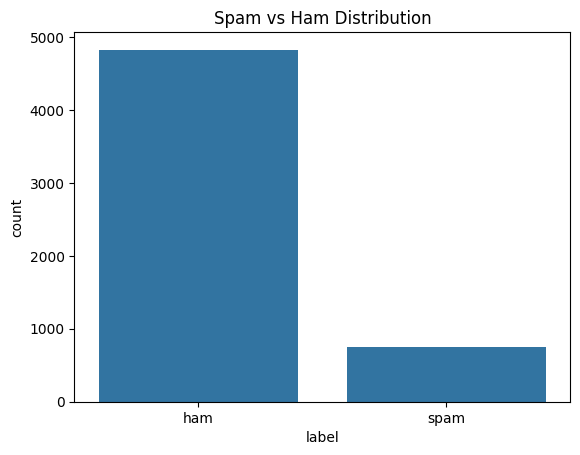

In [35]:
sns.countplot(x='label', data=data)
plt.title("Spam vs Ham Distribution")
plt.show()

### Observation:

- The dataset is highly imbalanced
- Ham messages are significantly higher than spam messages
- Spam messages form a smaller portion of the dataset
- This imbalance may affect model performance and should be considered during modeling

## Feature Engineering: Message Length

We calculate the length of each message to analyze how message size differs between spam and ham messages.

In [36]:
data['message_length'] = data['message'].apply(len)

### Observation:

- A new feature 'message_length' is created
- This represents the number of characters in each message
- It will help in understanding text patterns and differences between spam and ham

In [37]:
data

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161
5568,ham,Will Ì_ b going to esplanade fr home?,37
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


## Visualization: Message Length Distribution (Before Cleaning)

A histogram is used to analyze the distribution of message lengths before applying text cleaning.

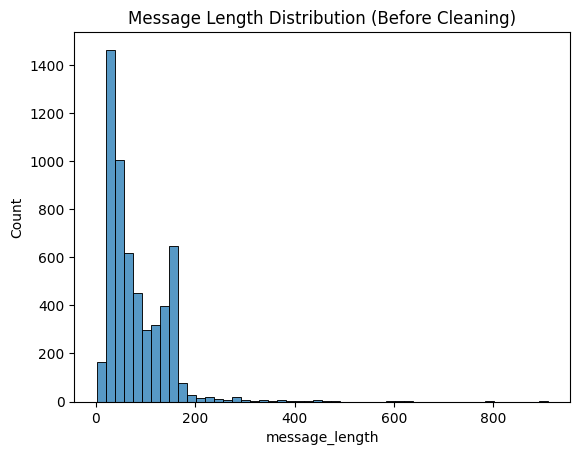

In [38]:
sns.histplot(data['message_length'], bins=50)
plt.title("Message Length Distribution (Before Cleaning)")
plt.show()

### Observation:

- Most messages have a length between 0 and 200 characters
- The distribution is right-skewed (long tail on the right)
- A few messages have very high length, indicating outliers
- These outliers are likely spam messages containing long promotional text

## Visualization: Message Length by Label

A boxplot is used to compare the distribution of message lengths between spam and ham messages.  
This helps identify differences in central tendency and the presence of outliers.

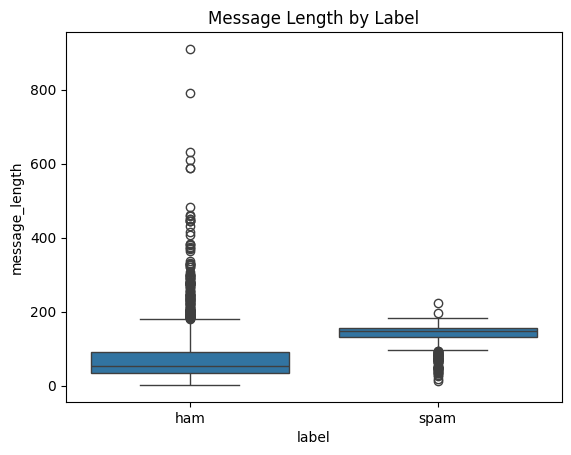

In [39]:
sns.boxplot(x='label', y='message_length', data=data)
plt.title("Message Length by Label")
plt.show()

### Observation:

- Spam messages generally have higher median message length compared to ham messages  
- Ham messages are shorter and more consistent in length  
- A large number of outliers are present, especially in ham messages  
- These outliers represent unusually long messages, likely promotional or detailed texts  

### Key Insight:

- Message length can be an important feature for distinguishing spam from ham messages  
- Spam messages tend to contain more content, making them longer on average

## Feature Engineering: Word Count

We calculate the number of words in each message to further analyze text characteristics and differences between spam and ham messages.

In [41]:
data['word_count'] = data['message'].apply(lambda x: len(x.split()))

### Observation:

- A new feature 'word_count' has been created  
- It represents the number of words in each message  
- This feature helps in understanding text structure and complexity  
- It will be useful for comparing spam and ham messages

In [42]:
data

,label,message,message_length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,30
5568,ham,Will Ì_ b going to esplanade fr home?,37,8
5569,ham,"Pity, * was in mood for that. So...any other s...",57,10
5570,ham,The guy did some bitching but I acted like i'd...,125,26


## Visualization: Word Count Distribution (Before Cleaning)

A histogram is used to analyze how the number of words varies across messages.

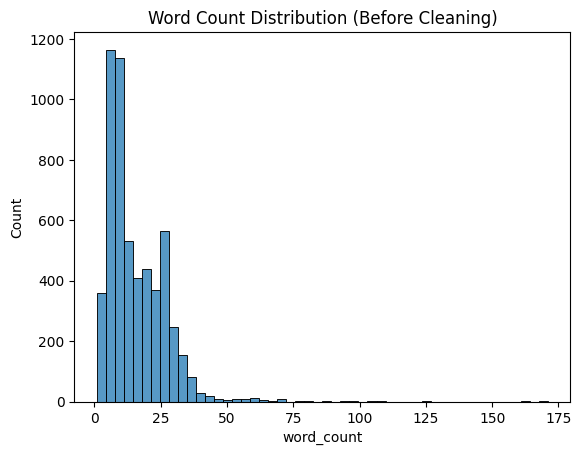

In [ ]:
sns.histplot(data['word_count'], bins=50) # bins= 50 (Divide your data into 50 equal groups (intervals) and count how many values fall into each group)
plt.title("Word Count Distribution (Before Cleaning)")
plt.show()

### Observation:

- Most messages contain between 5 to 25 words  
- The distribution is right-skewed (long tail on the right)  
- A few messages have very high word counts, indicating outliers  
- These longer messages are likely spam messages containing promotional or detailed content  

### Key Insight:

- Spam messages tend to have more words compared to regular messages  
- Word count is a useful feature for identifying spam patterns

## Visualization: Word Count by Label

A boxplot is used to compare the number of words in spam and ham messages.  
This helps in understanding differences in text length and identifying outliers.

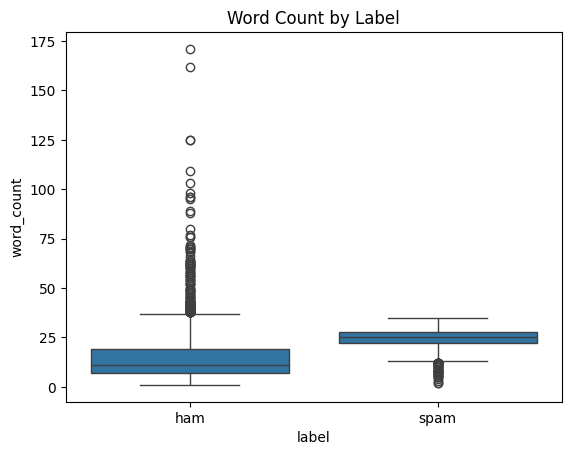

In [44]:
sns.boxplot(x='label', y='word_count', data=data)
plt.title("Word Count by Label")
plt.show()

### Observation:

- Spam messages generally have a higher word count compared to ham messages  
- Ham messages are shorter and more consistent in terms of word count  
- There are several outliers, especially in ham messages, indicating unusually long texts  
- Spam messages show a tighter distribution but higher median value  

### Key Insight:

- Word count is a strong feature for distinguishing spam from ham messages  
- Spam messages tend to include more words due to promotional or descriptive content

## Visualization: Message Length Distribution (Violin Plot)

A violin plot is used to visualize the distribution and density of message lengths for spam and ham messages.  
It combines features of both boxplot and histogram.

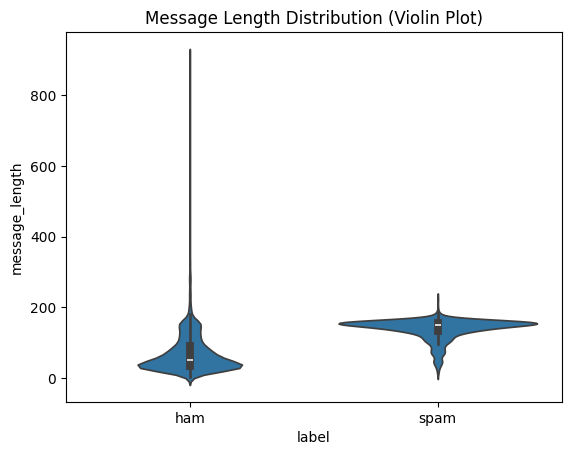

In [46]:
sns.violinplot(x='label', y='message_length', data=data)
plt.title("Message Length Distribution (Violin Plot)")
plt.show()

### Observation:


- Spam messages are longer  
- Ham messages are shorter but sometimes very long  
- Most spam messages have similar length  

### Key Insight:

- Message length helps in identifying spam messages 

## Raw Text Sample

Below are some original SMS messages before cleaning.  
These messages contain noise such as special characters, mixed casing, numbers, and unwanted text.

In [45]:
data['message'].head(10)

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
5    FreeMsg Hey there darling it's been 3 week's n...
6    Even my brother is not like to speak with me. ...
7    As per your request 'Melle Melle (Oru Minnamin...
8    WINNER!! As a valued network customer you have...
9    Had your mobile 11 months or more? U R entitle...
Name: message, dtype: str

### Observation:

- Messages contain special characters and punctuation  
- Text is not consistent (uppercase and lowercase mixed)  
- Some messages contain numbers and extra symbols  
- Cleaning is required before analysis

## Importing Regex Library

The `re` (regular expression) library is used for pattern matching and text cleaning.

In [47]:
import re

## Creating Cleaned Message Column

A new column `cleaned_message` is created to store the cleaned version of the original text.

In [48]:
data['cleaned_message'] = data['message']

## Step 1: Convert Text to Lowercase

All text is converted to lowercase to ensure uniformity and avoid duplicate variations of the same words.

In [49]:
data['cleaned_message'] = data['cleaned_message'].str.lower()

### Observation:

- All uppercase letters are converted to lowercase  
- Helps in consistent text analysis  

## Step 2: Remove URLs

URLs such as http links and www links are removed as they do not add meaningful information for analysis.

In [50]:
r'http\S+|www\S+'

'http\\S+|www\\S+'

In [51]:
data['cleaned_message'] = data['cleaned_message'].apply(
    lambda x: re.sub(r'http\S+|www\S+', '', x)
)

### Observation:

- All website links are removed  
- Helps in reducing noise from the text  

In [52]:
data[['message', 'cleaned_message']].head(5)

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


## Step 3: Remove Numbers

Numbers are removed from the text as they usually do not contribute meaningful information for text analysis.

In [53]:
r'\d+'

'\\d+'

In [54]:
data['cleaned_message'] = data['cleaned_message'].apply(
    lambda x: re.sub(r'\d+', '', x)
)

### Observation:

- All numeric values are removed from the messages  
- Helps in reducing noise in the dataset  
- Improves text consistency  

## Step 4: Remove Special Characters

Special characters such as punctuation and symbols are removed to clean the text.

In [55]:
r'[^\w\s]'

'[^\\w\\s]'

In [56]:
data['cleaned_message'] = data['cleaned_message'].apply(
    lambda x: re.sub(r'[^\w\s]', '', x)
)

### Observation:

- Special characters like punctuation marks are removed  
- Text becomes cleaner and easier to analyze  

## Step 5: Remove Extra Spaces

After removing numbers and special characters, extra spaces may appear in the text.  
These are removed to make the text clean and properly formatted.

In [57]:
r'\s+'

'\\s+'

In [58]:
data['cleaned_message'] = data['cleaned_message'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

### Observation:

- Multiple spaces are replaced with a single space  

In [59]:
data[['message', 'cleaned_message']].head(10)

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


## Step 6: Remove Single Characters

Single characters such as 'u', 'r', 'a' often do not carry meaningful information in text analysis.  
Removing them helps improve text quality for machine learning models.

In [60]:
data['cleaned_message'] = data['cleaned_message'].apply(
    lambda x: re.sub(r'\b[a-zA-Z]\b', '', x)
)

\b = word boundary
[a-zA-Z] = any single letter
\b[a-zA-Z]\b = matches single-character words only

Example - Before --"u r going to a party"  and After -- "going to party"

In [61]:
data['cleaned_message'] = data['cleaned_message'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

re.sub(r'\s+', ' ', x) -- \s = any whitespace (space, tab, newline) and + = one or more, so \s+  →  multiple spaces, 
Replace:
"hello    world"
With:
"hello world"

.strip()
 Removes spaces from:beginning and end

### Observation:

- Single-character words are removed from the text  
- Text becomes more meaningful and less noisy  
- Extra spaces created after removal are cleaned again  

In [62]:
data['cleaned_message'] = data['cleaned_message'].apply(
    lambda x: re.sub(r'(.)\1+', r'\1\1', x)
)

In [63]:
data['cleaned_message'] = data['cleaned_message'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

In [64]:
data[['message', 'cleaned_message']].head(10)

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in wkly comp to win fa cup final tk...
3,U dun say so early hor... U c already then say...,dun say so early hor already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think he goes to usf he lives around ...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as valued network customer you have bee...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more entitled to upd...


## Normalize Repeated Characters

Repeated characters like "heyyyy" or "nooooo" are common in text messages.  
This step reduces excessive repetitions to two characters to maintain meaning while reducing noise.

### Observation:

- Words with repeated characters are normalized  
- Text becomes cleaner and more consistent  
- Helps improve model performance  

## Feature Engineering on Cleaned Text

After cleaning the text, we create new features to analyze the processed messages more effectively.

- **cleaned_length**: Number of characters in the cleaned message  
- **cleaned_word_count**: Number of words in the cleaned message  

These features help in understanding how text cleaning has impacted message size and structure.

In [65]:
data['cleaned_length'] = data['cleaned_message'].apply(len)

data['cleaned_word_count'] = data['cleaned_message'].apply(lambda x: len(x.split()))

In [71]:
data

,label,message,message_length,word_count,cleaned_message,cleaned_length,cleaned_word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,go until jurong point crazy available only in ...,98,18
1,ham,Ok lar... Joking wif u oni...,29,6,ok lar joking wif oni,21,5
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,free entry in wkly comp to win fa cup final tk...,119,24
3,ham,U dun say so early hor... U c already then say...,49,11,dun say so early hor already then say,37,8
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,nah dont think he goes to usf he lives around ...,57,12
...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,30,this is the nd time we have tried contact have...,122,24
5568,ham,Will Ì_ b going to esplanade fr home?,37,8,will ì_ going to esplanade fr home,34,7
5569,ham,"Pity, * was in mood for that. So...any other s...",57,10,pity was in mood for that soany other suggestions,49,9
5570,ham,The guy did some bitching but I acted like i'd...,125,26,the guy did some bitching but acted like id be...,122,25


### Observation:

- Cleaned messages generally have shorter length compared to original messages  
- Word count may reduce after removing noise such as special characters and extra spaces  
- Cleaned features provide a more accurate representation of meaningful text  

## Message Length Comparison (Before vs After Cleaning)

This visualization compares the distribution of message length before and after text cleaning.

- **Before Cleaning**: Original message length  
- **After Cleaning**: Length after removing noise (URLs, numbers, special characters, etc.)

This helps us understand how cleaning affects the size of the text data.

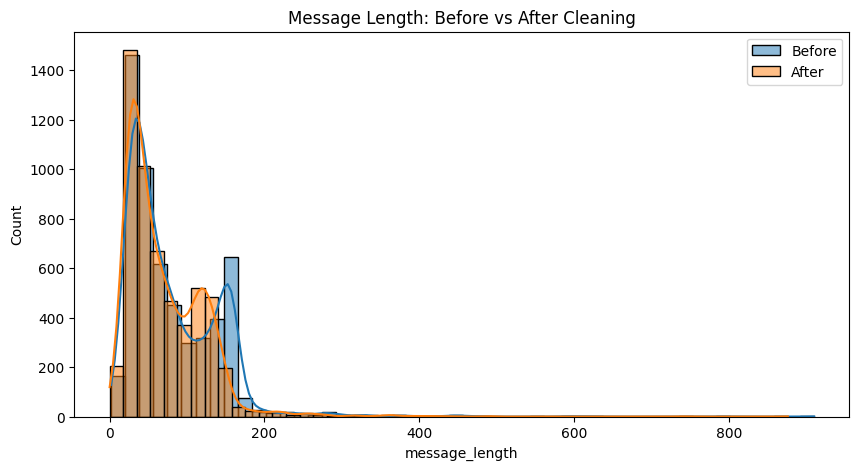

In [66]:
plt.figure(figsize=(10,5))

sns.histplot(data['message_length'], bins=50, label='Before', kde=True)
sns.histplot(data['cleaned_length'], bins=50, label='After', kde=True)

plt.legend()
plt.title("Message Length: Before vs After Cleaning")
plt.show()

### Observation:

- Message length decreases after cleaning  
- The "After" distribution is slightly shifted towards smaller values  
- Extreme long messages are reduced after removing noise  

### Key Insight:

- Text cleaning removes unnecessary characters, making messages shorter and more meaningful  
- Cleaned data is more suitable for machine learning models  

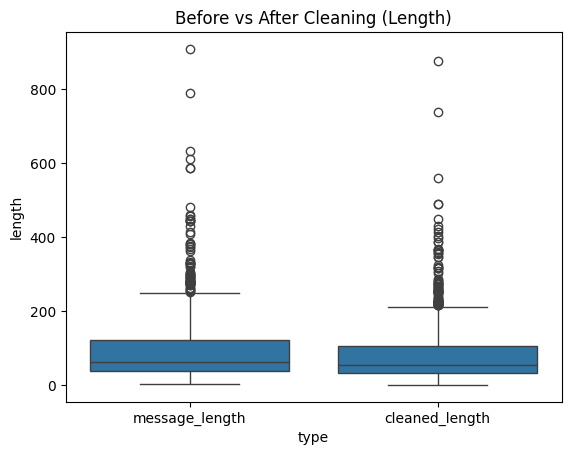

In [67]:
comparison_df = data[['message_length', 'cleaned_length']]
comparison_df = comparison_df.melt(var_name='type', value_name='length')

sns.boxplot(x='type', y='length', data=comparison_df)
plt.title("Before vs After Cleaning (Length)")
plt.show()

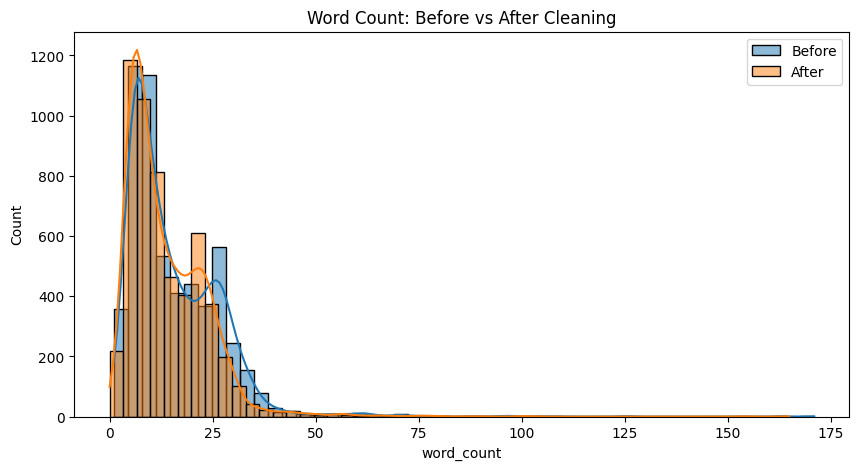

In [68]:
plt.figure(figsize=(10,5))

sns.histplot(data['word_count'], bins=50, label='Before', kde=True)
sns.histplot(data['cleaned_word_count'], bins=50, label='After', kde=True)

plt.legend()
plt.title("Word Count: Before vs After Cleaning")
plt.show()

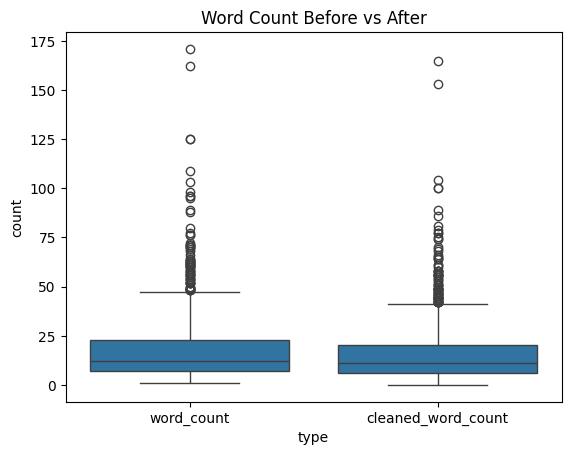

In [69]:
comparison_wc = data[['word_count', 'cleaned_word_count']]
comparison_wc = comparison_wc.melt(var_name='type', value_name='count')

sns.boxplot(x='type', y='count', data=comparison_wc)
plt.title("Word Count Before vs After")
plt.show()

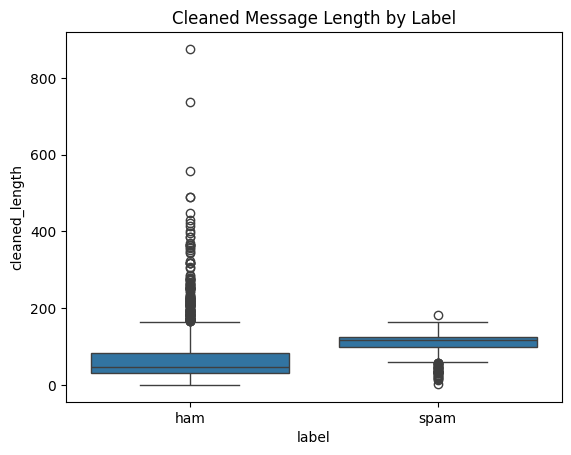

In [70]:
sns.boxplot(x='label', y='cleaned_length', data=data)
plt.title("Cleaned Message Length by Label")
plt.show()